Здесь живет некоторый тект

In [1]:
import shutil
print(shutil.which('xelatex'))

C:\Users\vano2\AppData\Local\Programs\MiKTeX\miktex\bin\x64\xelatex.EXE


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import binned_statistic_2d
from scipy.ndimage import gaussian_filter

In [3]:
data_with = np.load("trajectories_with_borders.npz")
data_without = np.load("trajectories_without_borders.npz")

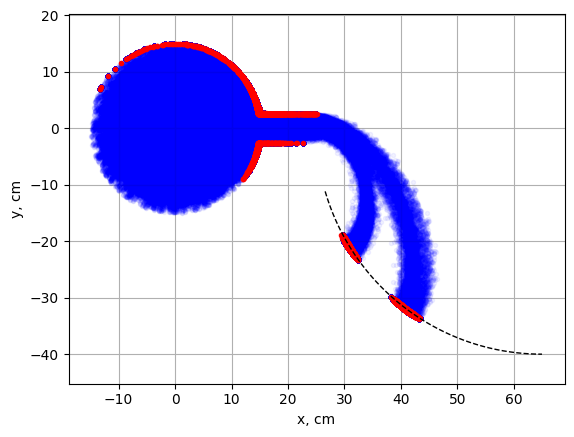

In [4]:
poses_with = data_with["poses"]
vels_with = data_with["vels"]

plt.plot(poses_with[::2, ::5, 0].flatten(), poses_with[::2, ::5, 1].flatten(), "b.", alpha=0.05)

plt.plot(poses_with[:, -1, 0].flatten(), poses_with[:, -1, 1].flatten(), "r.")

plt.axis("equal")
plt.xlabel("x, cm")
plt.ylabel("y, cm")
circle_phi = np.linspace(-0.91, -0.5, 500) * np.pi
plt.plot(65 + 40 * np.cos(circle_phi), 40*np.sin(circle_phi), "k--", lw=1)
plt.grid()
plt.show()



<img src="photo_2026-03-23_19-36-10-2.jpg" width="400" /> <img src="photo_2026-03-23_19-47-17.jpg" width="400" />


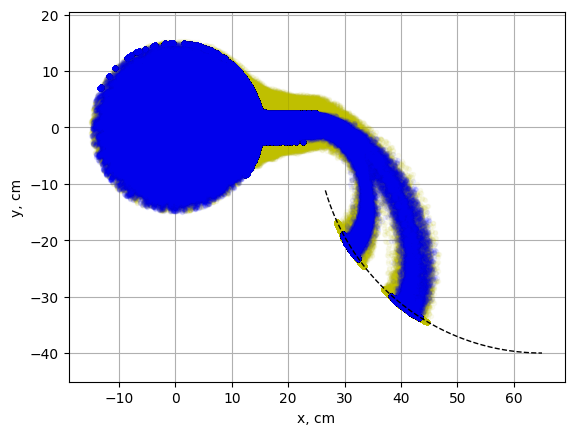

In [5]:
poses_without = data_without["poses"]
vels_without = data_without["vels"]

rs_without = np.linalg.norm(poses_without - np.array([65, 0, 0]), axis=2)

collision_idxs_without = np.argmax((rs_without > 40) * (poses_without[:, :, 1] < -10) * (poses_without[:, :, 0] > 25), axis=1)
if np.any(collision_idxs_without == 0):
    raise Exception("some are not collected")



rows = np.arange(poses_without.shape[0])[:, None]
cols = np.arange(poses_without.shape[1])[None, :]
poses_without_collected = poses_without[rows, np.minimum(cols, collision_idxs_without[:, None])]

plt.plot(poses_without_collected[::2, ::5, 0].flatten(), poses_without_collected[::2, ::5, 1].flatten(), "y.", alpha=0.05)

plt.plot(poses_with[::2, ::5, 0].flatten(), poses_with[::2, ::5, 1].flatten(), "b.", alpha=0.05)

plt.axis("equal")
plt.xlabel("x, cm")
plt.ylabel("y, cm")

plt.plot(65 + 40 * np.cos(circle_phi), 40*np.sin(circle_phi), "k--", lw=1)
plt.grid()
plt.show()

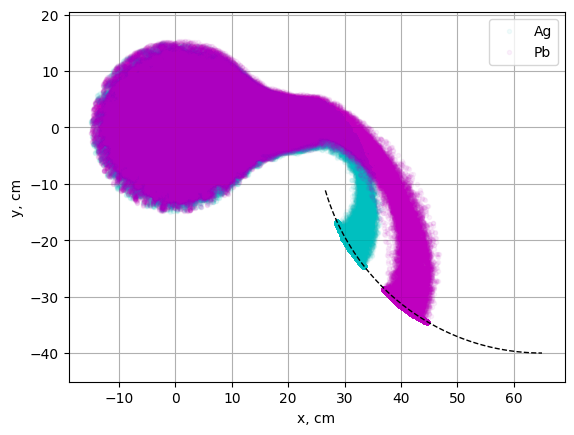

In [6]:
poses_without_collected_Ag = poses_without_collected[:5000]
poses_without_collected_Pb = poses_without_collected[5000:]

vels_without_collected_Ag = vels_without[:5000]
vels_without_collected_Pb = vels_without[5000:]


plt.plot(poses_without_collected[:5000:2, ::5, 0].flatten(), poses_without_collected[:5000:2, ::5, 1].flatten(), "c.", alpha=0.05, label="Ag")
plt.plot(poses_without_collected[5000::2, ::5, 0].flatten(), poses_without_collected[5000::2, ::5, 1].flatten(), "m.", alpha=0.05, label="Pb")

plt.axis("equal")
plt.xlabel("x, cm")
plt.ylabel("y, cm")
plt.legend()

plt.plot(65 + 40 * np.cos(circle_phi), 40*np.sin(circle_phi), "k--", lw=1)
plt.grid()
plt.show()

In [7]:
rs_with = np.linalg.norm(poses_with - np.array([65, 0, 0]), axis=2)

collision_idxs_with = np.argmax((rs_with > 40) * (poses_with[:, :, 1] < -10) * (poses_with[:, :, 0] > 25), axis=1)
print("wasted total: ", np.sum(collision_idxs_with == 0))
print("wasted Ag: ", np.sum(collision_idxs_with[:5000] == 0))
print("wasted Pb: ", np.sum(collision_idxs_with[5000:] == 0))

poses_with_collected = poses_with[collision_idxs_with != 0]
vels_with_collected = vels_with[collision_idxs_with != 0]

i_ion_mass = np.argmax(data_with["ions_mass"][collision_idxs_with != 0])

poses_with_collected_Ag = poses_with_collected[:i_ion_mass]
poses_with_collected_Pb = poses_with_collected[i_ion_mass:]

vels_with_collected_Ag = vels_with_collected[:i_ion_mass]
vels_with_collected_Pb = vels_with_collected[i_ion_mass:]

wasted total:  3894
wasted Ag:  1722
wasted Pb:  2172


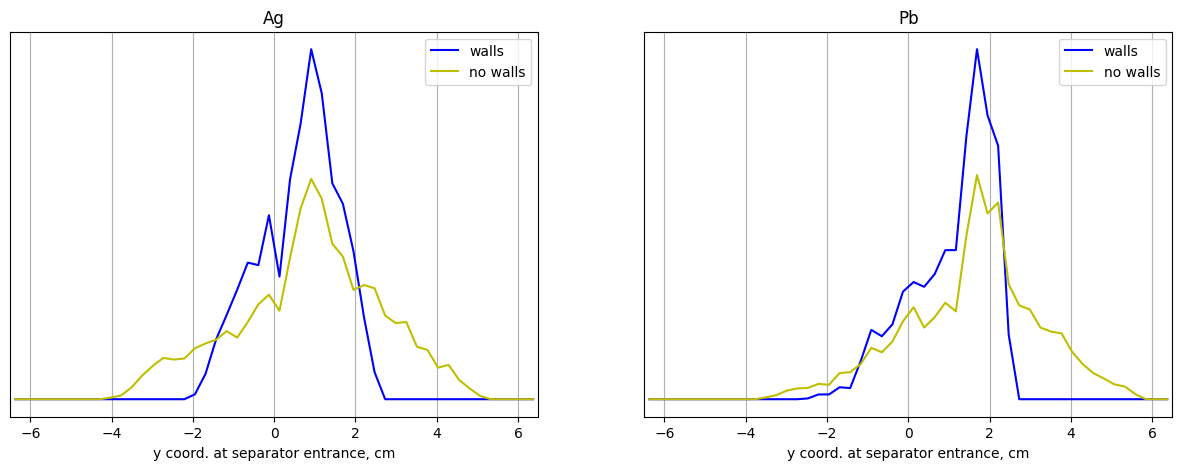

In [8]:
x_range = (-6.5, 6.5)


def y_entrance_plot(ax, poses, f, label):
    counts, bins  = np.histogram(poses[:, :, 1][np.arange(poses.shape[0]), np.argmax(poses[:, :, 0]>25, axis=1)], 50, x_range, density=True)
    bins = bins[:-1] + 0.5*(bins[1] - bins[0])
    ax.plot(bins, counts,  f, label=label)
    

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].set_title("Ag")
y_entrance_plot(axs[0], poses_with_collected_Ag, "b-", "walls")
y_entrance_plot(axs[0], poses_without_collected_Ag, "y-", "no walls")


axs[1].set_title("Pb")
y_entrance_plot(axs[1], poses_with_collected_Pb, "b-", "walls")
y_entrance_plot(axs[1], poses_without_collected_Pb, "y-", "no walls")

for ax in axs:
    ax.set_xlabel("y coord. at separator entrance, cm")
    ax.set_yticks([])
    ax.grid()
    ax.legend()
    ax.set_xlim(x_range)

plt.show()

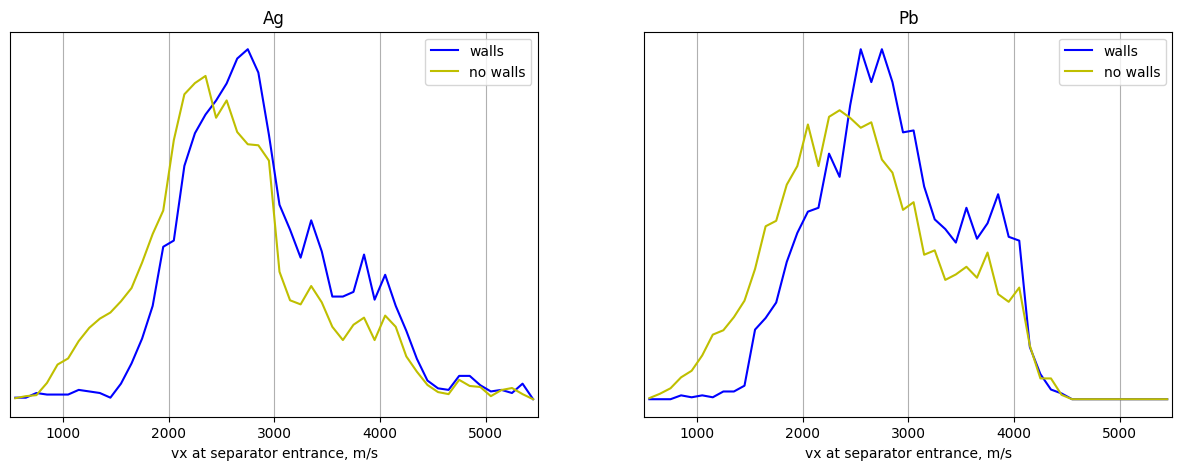

In [9]:
x_range = (500, 5500)


def vx_entrance_plot(ax, poses, vels, f, label):
    counts, bins  = np.histogram(vels[:, :, 0][np.arange(poses.shape[0]), np.argmax(poses[:, :, 0]>25, axis=1)], 50, x_range, density=True)
    bins = bins[:-1] + 0.5*(bins[1] - bins[0])
    ax.plot(bins, counts,  f, label=label)
    

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].set_title("Ag")

vx_entrance_plot(axs[0], poses_with_collected_Ag, vels_with_collected_Ag, "b-", "walls")
vx_entrance_plot(axs[0], poses_without_collected_Ag, vels_without_collected_Ag, "y-", "no walls")


axs[1].set_title("Pb")
vx_entrance_plot(axs[1], poses_with_collected_Pb, vels_with_collected_Pb, "b-", "walls")
vx_entrance_plot(axs[1], poses_without_collected_Pb, vels_without_collected_Pb, "y-", "no walls")

for ax in axs:
    ax.set_xlabel("vx at separator entrance, m/s")
    ax.set_yticks([])
    ax.grid()
    ax.legend()
    ax.set_xlim(x_range)


plt.show()

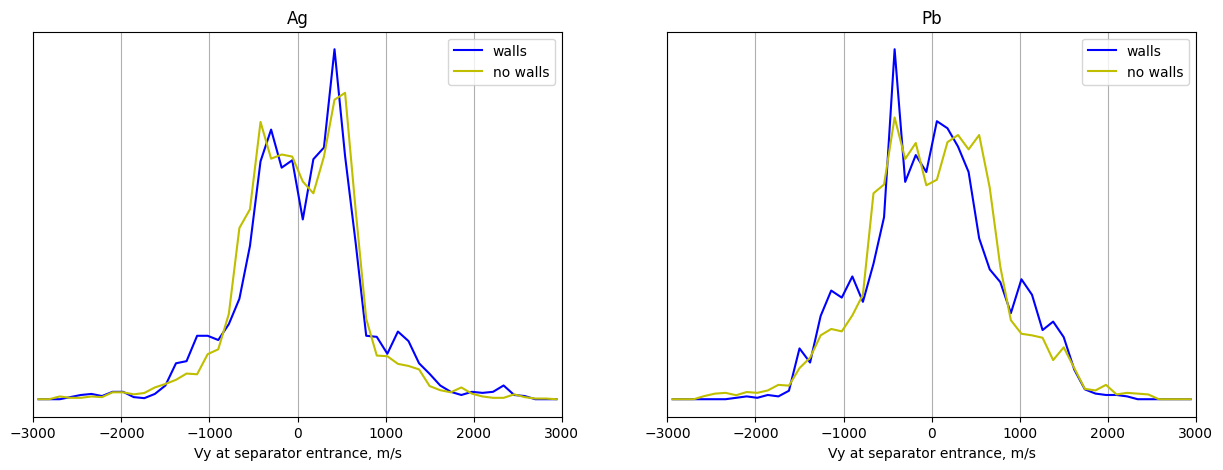

In [48]:
x_range = (-3000, 3000)


def vy_entrance_plot(ax, poses, vels, f, label):
    counts, bins  = np.histogram(vels[:, :, 1][np.arange(poses.shape[0]), np.argmax(poses[:, :, 0]>25, axis=1)], 50, x_range, density=True)
    bins = bins[:-1] + 0.5*(bins[1] - bins[0])
    ax.plot(bins, counts,  f, label=label)
    

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].set_title("Ag")

vy_entrance_plot(axs[0], poses_with_collected_Ag, vels_with_collected_Ag, "b-", "walls")
vy_entrance_plot(axs[0], poses_without_collected_Ag, vels_without_collected_Ag, "y-", "no walls")


axs[1].set_title("Pb")
vy_entrance_plot(axs[1], poses_with_collected_Pb, vels_with_collected_Pb, "b-", "walls")
vy_entrance_plot(axs[1], poses_without_collected_Pb, vels_without_collected_Pb, "y-", "no walls")

for ax in axs:
    ax.set_xlabel("Vy at separator entrance, m/s")
    ax.set_yticks([])
    ax.grid()
    ax.legend()
    ax.set_xlim(x_range)

plt.show()

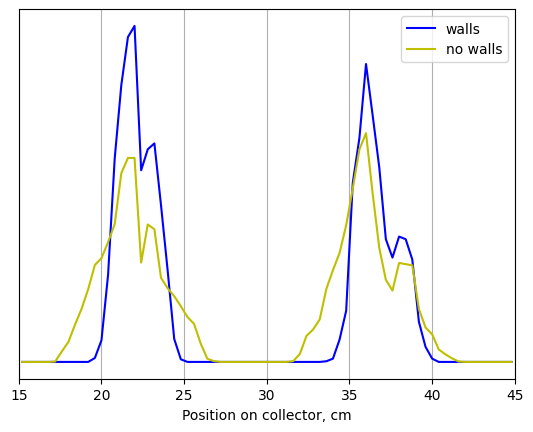

In [11]:
x_range = (15, 45)

def plot_poses_on_collector(poses, f, label):
    poses_centered = poses[:, -1, :] - np.array([65, 0, 0])
    phis = np.atan2(poses_centered[:, 1], poses_centered[:, 0]) + np.pi
    counts, bins = np.histogram(40*phis, 75, x_range, density=True)
    bins = bins[:-1] + 0.5*(bins[1] - bins[0])
    plt.plot(bins, counts,  f, label=label)

plot_poses_on_collector(poses_with_collected, "b-", "walls")
plot_poses_on_collector(poses_without_collected, "y-", "no walls")

plt.xlabel("Position on collector, cm")
plt.yticks([])
plt.grid()
plt.legend()
plt.xlim(x_range)

plt.show()



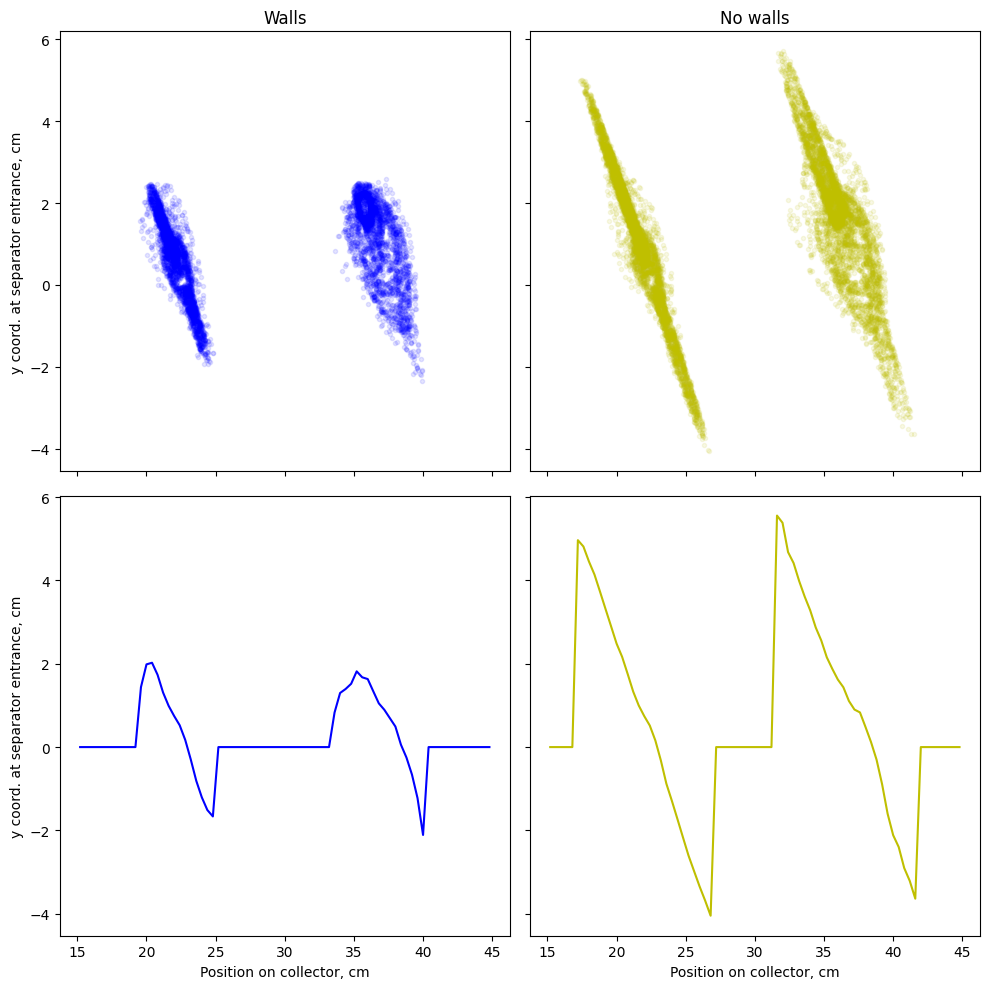

In [46]:
x_range = (15, 45)

def plot_poses_on_collector_vs_entrance_hist(ax, poses, f):
    poses_centered = poses[:, -1, :] - np.array([65, 0, 0])
    phis = np.atan2(poses_centered[:, 1], poses_centered[:, 0]) + np.pi
    sums, bins = np.histogram(40*phis, 75, x_range, 
                                weights=poses[:, :, 1][np.arange(poses.shape[0]), np.argmax(poses[:, :, 0]>25, axis=1)])
    counts, _ = np.histogram(40*phis, 75, x_range)
    counts += counts == 0
    bins = bins[:-1] + 0.5*(bins[1] - bins[0])

    ax.plot(bins, sums / counts,  f)


def plot_poses_on_collector_vs_entrance_dots(ax, poses, f, alpha):
    poses_centered = poses[:, -1, :] - np.array([65, 0, 0])
    phis = np.atan2(poses_centered[:, 1], poses_centered[:, 0]) + np.pi
    counts, bins = np.histogram(40*phis, 75, x_range, 
                                weights=poses[:, :, 1][np.arange(poses.shape[0]), np.argmax(poses[:, :, 0]>25, axis=1)], 
                                density=True)
    bins = bins[:-1] + 0.5*(bins[1] - bins[0])

    ax.plot(40*phis, poses[:, :, 1][np.arange(poses.shape[0]), np.argmax(poses[:, :, 0]>25, axis=1)],  f, alpha=alpha)

fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey="row")

plot_poses_on_collector_vs_entrance_dots(axs[0, 0], poses_with_collected, "b.", 0.1)
plot_poses_on_collector_vs_entrance_dots(axs[0, 1], poses_without_collected, "y.", 0.1)

plot_poses_on_collector_vs_entrance_hist(axs[1, 0], poses_with_collected, "b")
plot_poses_on_collector_vs_entrance_hist(axs[1, 1], poses_without_collected, "y")

axs[0, 0].set_title("Walls")
axs[0, 1].set_title("No walls")

for ax in axs[:, 0]:
    ax.set_ylabel("y coord. at separator entrance, cm")
for ax in axs[1, :]:
    ax.set_xlabel("Position on collector, cm")

plt.tight_layout()


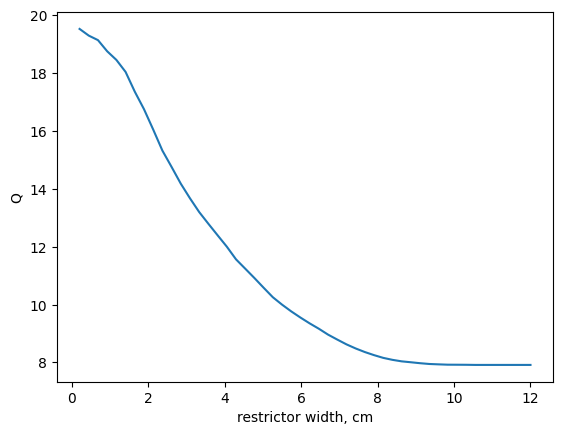

In [91]:
def y_at_entrance(poses):
    return poses[:, :, 1][np.arange(poses.shape[0]), np.argmax(poses[:, :, 0]>25, axis=1)]

def pos_on_collector(poses):
    poses_centered = poses[:, -1, :] - np.array([65, 0, 0])
    phis = np.atan2(poses_centered[:, 1], poses_centered[:, 0]) + np.pi
    return 40 * phis

def quality(poses_Ag, poses_Pb):
    poses_on_collector_Ag = pos_on_collector(poses_Ag)
    poses_on_collector_Pb = pos_on_collector(poses_Pb)
    return 2 * (poses_on_collector_Pb.mean() - poses_on_collector_Ag.mean()) / (poses_on_collector_Pb.std() + poses_on_collector_Ag.std())

def restricted(poses, width):
    ys = y_at_entrance(poses)
    ys -= ys.mean()
    return poses[(ys < width/2) * (ys > -width/2) > 0]


widths = np.linspace(0.2, 12, 50)
qualities = [quality(restricted(poses_without_collected_Ag, width), restricted(poses_without_collected_Pb, width)) for width in widths]

plt.plot(widths, qualities)
plt.xlabel("restrictor width, cm")
plt.ylabel("Q")
plt.show()

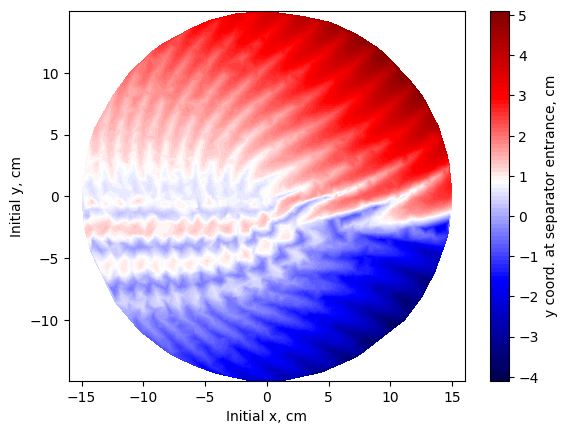

In [45]:
poses = poses_without_collected_Ag
x, y = poses[:, 0, :2].T
z = poses[:, :, 1][np.arange(poses.shape[0]), np.argmax(poses[:, :, 0]>25, axis=1)]

norm = TwoSlopeNorm(vcenter=np.mean(z))
plt.tricontourf(x, y, z, levels=100, cmap='seismic', norm=norm)
plt.axis("equal")
plt.xlabel("Initial x, cm")
plt.ylabel("Initial y, cm")
plt.colorbar(label="y coord. at separator entrance, cm")

In [ ]:
sigma = 15.0   # controls smoothness
nx = ny = 400   # this is now BOTH your grid + resolution

def plot_initial_colored(ax, x, y, z, colormap_label):
    # =========================
    # 2. BINNING (mean via sum/count → faster & flexible)
    # =========================
    

    # Sum of values
    z_sum, x_edges, y_edges, _ = binned_statistic_2d(
        x, y, z, statistic='sum', bins=[nx, ny]
    )

    # Count of points
    count, _, _, _ = binned_statistic_2d(
        x, y, z, statistic='count', bins=[nx, ny]
    )

    # Avoid division by zero
    with np.errstate(invalid='ignore'):
        grid = z_sum / count

    # =========================
    # 3. SMOOTHING (key step)
    # =========================
    # Fill NaNs with 0 temporarily
    grid_filled = np.nan_to_num(grid, nan=0.0)
    weight = (~np.isnan(grid)).astype(float)

    # Smooth both signal and weights

    grid_smooth = gaussian_filter(grid_filled, sigma=sigma)
    weight_smooth = gaussian_filter(weight, sigma=sigma)

    # Normalize → proper smoothing
    with np.errstate(invalid='ignore'):
        grid_smooth /= weight_smooth

    # =========================
    # 4. Mask outside circle
    # =========================
    x_cent = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_cent = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_cent, y_cent)

    radius = np.sqrt(Xc**2 + Yc**2)
    grid_smooth[radius > 15.0] = np.nan

    # =========================
    # 5. Plot
    # =========================
    norm = TwoSlopeNorm(vcenter=np.mean(z))
    c = ax.pcolormesh(
        x_edges,
        y_edges,
        grid_smooth.T,
        shading='auto',
        cmap='seismic',   # or any diverging colormap
        norm=norm,
    )
    plt.colorbar(c, ax=ax, label=colormap_label)


def plot_initial_colored_by_f(ax, poses, f, colormap_label):
    plot_initial_colored(ax, poses[:, 0, 0], poses[:, 0, 1], f(poses), colormap_label)

def all_colored_plots(poses_with, poses_without, title):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

    fig.suptitle(title)

    axs[0, 0].set_title("Walls")
    axs[0, 1].set_title("No walls")

    for ax in axs.flatten():
        ax.set_xlabel("Initial x, cm")
        ax.set_ylabel("Initial y, cm")

    plot_initial_colored_by_f(axs[0, 0], poses_with, pos_on_collector, "Position on collector, cm")
    plot_initial_colored_by_f(axs[0, 1], poses_without, pos_on_collector, "Position on collector, cm")

    plot_initial_colored_by_f(axs[1, 0], poses_with, y_at_entrance, "y coord. at separator entrance, cm")
    plot_initial_colored_by_f(axs[1, 1], poses_without, y_at_entrance, "y coord. at separator entrance, cm")

    plt.tight_layout()
    plt.show()

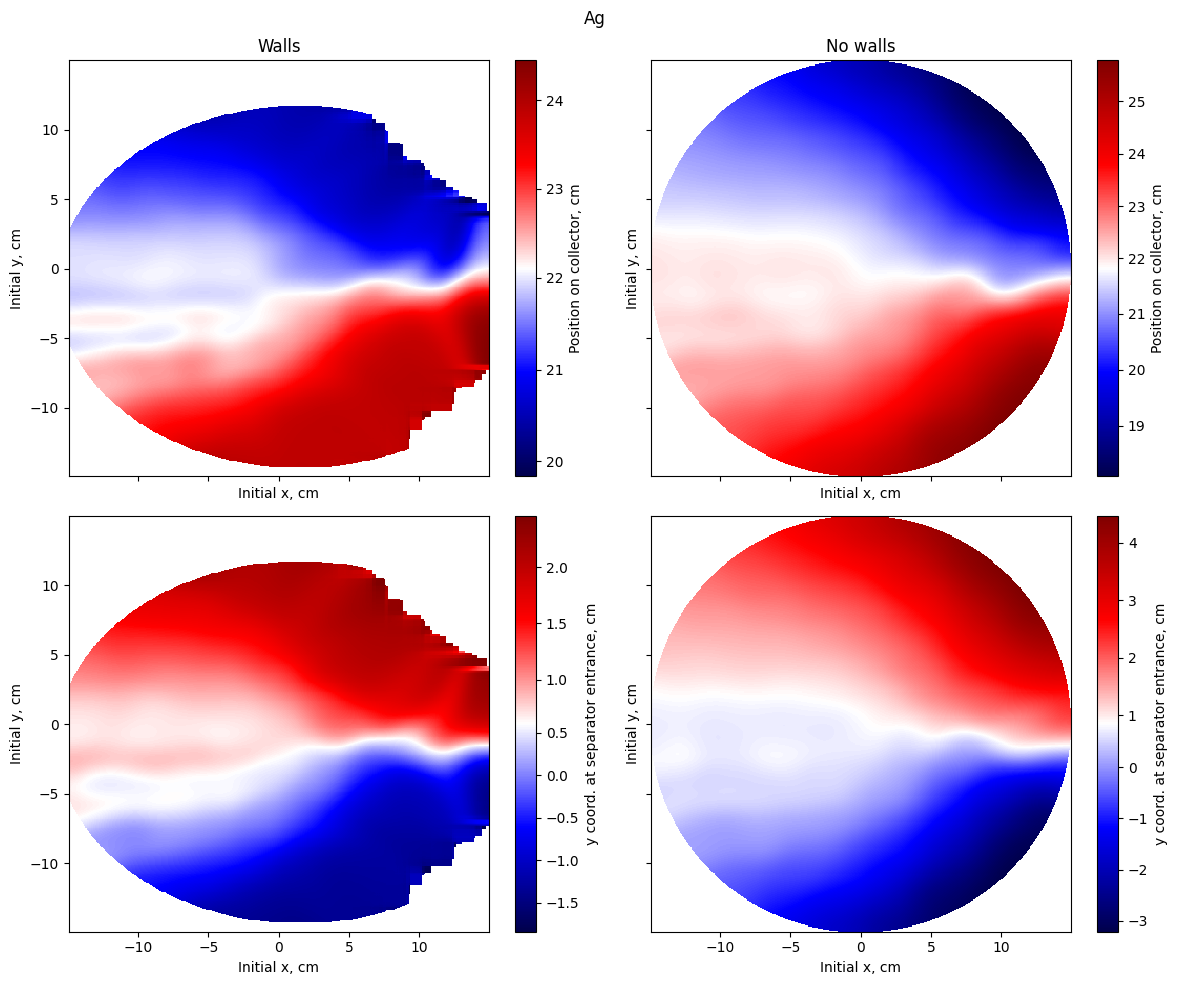

In [80]:
all_colored_plots(poses_with_collected_Ag, poses_without_collected_Ag, "Ag")

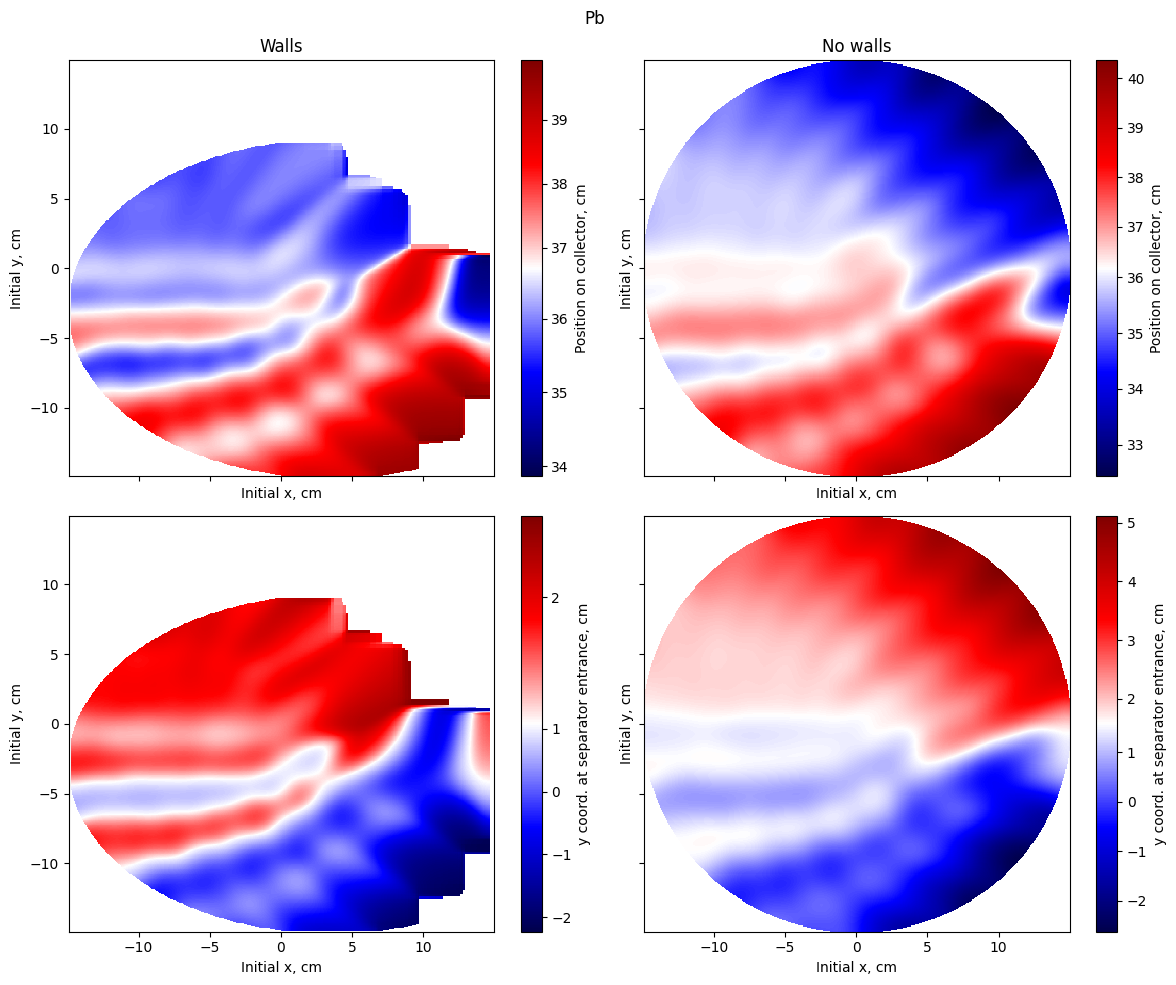

In [81]:
all_colored_plots(poses_with_collected_Pb, poses_without_collected_Pb, "Pb")

Text(0, 0.5, 'width over y at x, cm')

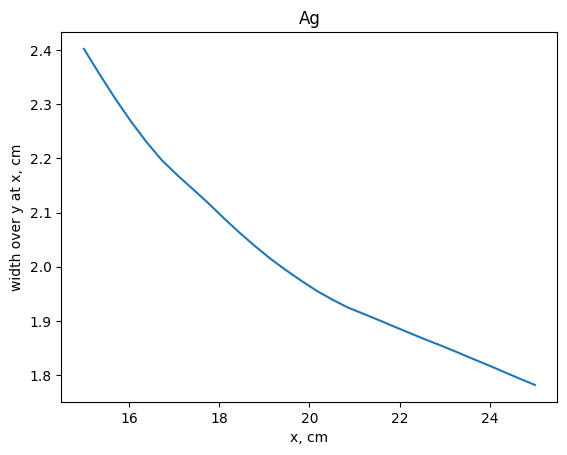

In [94]:
def y_at_x(poses, x):
    return poses[:, :, 1][np.arange(poses.shape[0]), np.argmax(poses[:, :, 0]>x, axis=1)]


xs = np.linspace(15, 25, 30)
widths = [y_at_x(poses_without_collected_Ag, x).std() for x in xs]
plt.plot(xs, widths)
plt.title("Ag")
plt.xlabel("x, cm")
plt.ylabel("width over y at x, cm")